In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set default style
sns.set(style="whitegrid")

In [15]:
df = pd.read_csv(r"D://Guvi//Projects//mini//Amazon Delivery Time Prediction//Amazon_delivery_time_prediction//data//raw//amazon_delivery.csv")
df.head()

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys


In [16]:
print(df.shape)

(43739, 16)


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         43739 non-null  object 
 1   Agent_Age        43739 non-null  int64  
 2   Agent_Rating     43685 non-null  float64
 3   Store_Latitude   43739 non-null  float64
 4   Store_Longitude  43739 non-null  float64
 5   Drop_Latitude    43739 non-null  float64
 6   Drop_Longitude   43739 non-null  float64
 7   Order_Date       43739 non-null  object 
 8   Order_Time       43739 non-null  object 
 9   Pickup_Time      43739 non-null  object 
 10  Weather          43648 non-null  object 
 11  Traffic          43739 non-null  object 
 12  Vehicle          43739 non-null  object 
 13  Area             43739 non-null  object 
 14  Delivery_Time    43739 non-null  int64  
 15  Category         43739 non-null  object 
dtypes: float64(5), int64(2), object(9)
memory usage: 5.3+ MB


In [18]:
df.describe()

,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Delivery_Time
count,43739.000000,43685.000000,43739.000000,43739.000000,43739.000000,43739.000000,43739.000000
mean,29.567137,4.633780,17.210960,70.661177,17.459031,70.821842,124.905645
std,5.815155,0.334716,7.764225,21.475005,7.342950,21.153148,51.915451
min,15.000000,1.000000,-30.902872,-88.366217,0.010000,0.010000,10.000000
25%,25.000000,4.500000,12.933298,73.170283,12.985996,73.280000,90.000000
50%,30.000000,4.700000,18.551440,75.898497,18.633626,76.002574,125.000000
75%,35.000000,4.900000,22.732225,78.045359,22.785049,78.104095,160.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,270.000000


## Missing Values

In [19]:
df.isnull().sum()

Order_ID            0
Agent_Age           0
Agent_Rating       54
Store_Latitude      0
Store_Longitude     0
Drop_Latitude       0
Drop_Longitude      0
Order_Date          0
Order_Time          0
Pickup_Time         0
Weather            91
Traffic             0
Vehicle             0
Area                0
Delivery_Time       0
Category            0
dtype: int64

In [20]:
df.isnull().sum().sort_values(ascending=False)

Weather            91
Agent_Rating       54
Agent_Age           0
Order_ID            0
Store_Longitude     0
Drop_Latitude       0
Drop_Longitude      0
Store_Latitude      0
Order_Date          0
Order_Time          0
Pickup_Time         0
Traffic             0
Vehicle             0
Area                0
Delivery_Time       0
Category            0
dtype: int64

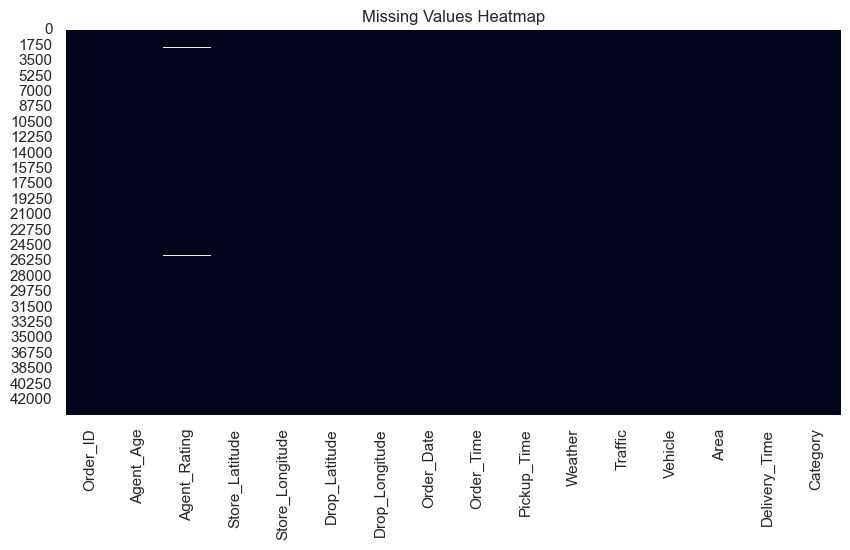

In [21]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

## Duplicate Check

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
# Separate Columns
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

# Univariate Analysis

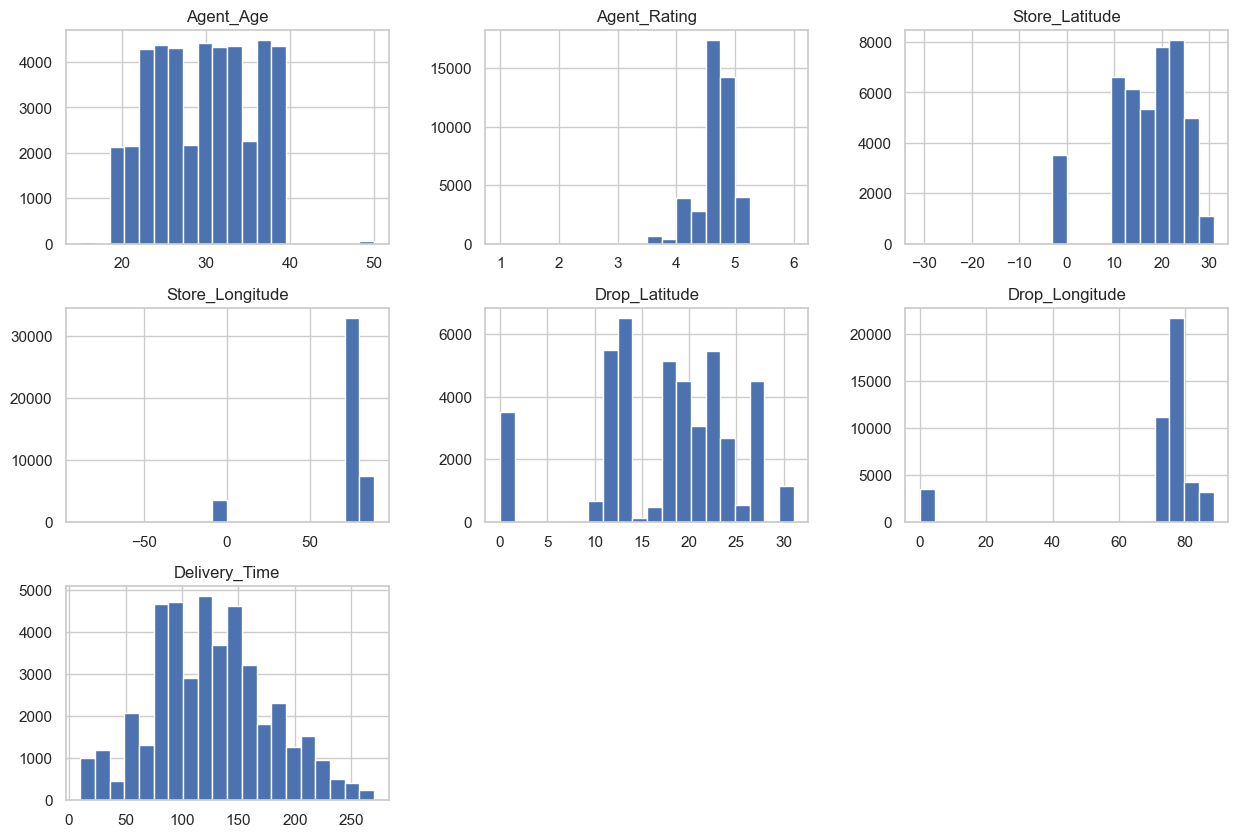

In [24]:
# Numerical Features
df[num_cols].hist(figsize=(15,10), bins=20)
plt.show()

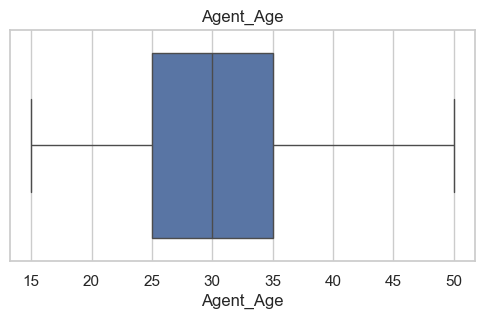

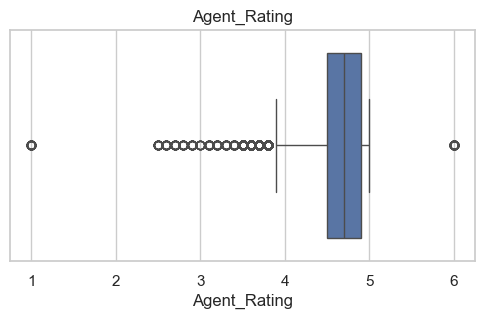

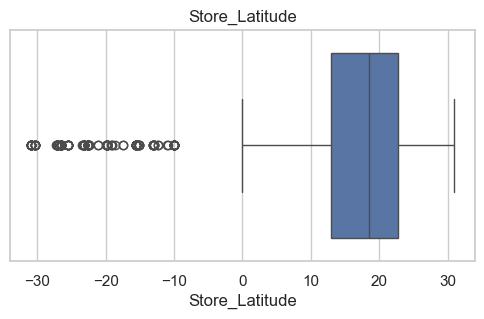

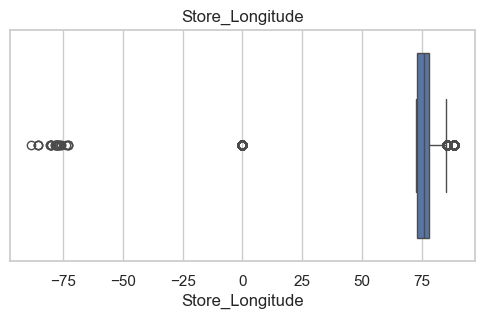

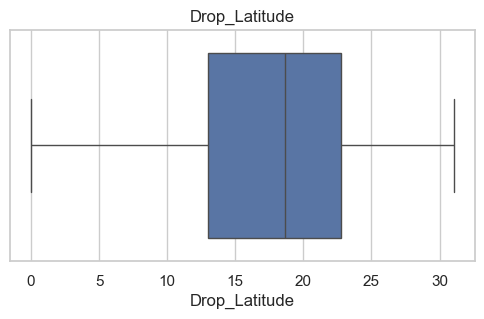

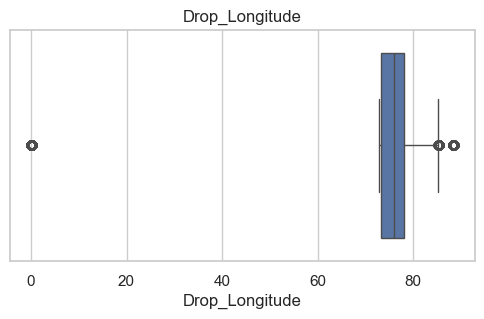

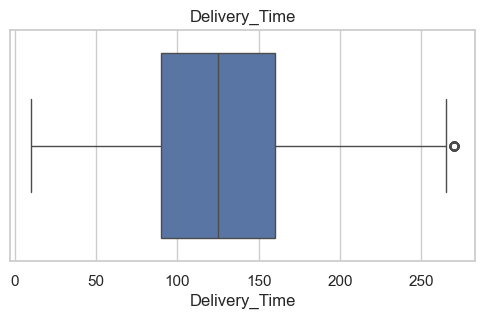

In [25]:
# Boxplot (Outliers)
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [26]:
# # Categorical Features
# for col in cat_cols:
#     plt.figure(figsize=(6,3))
#     sns.countplot(x=df[col])
#     plt.xticks(rotation=45)
#     plt.title(col)
#     plt.show()

### Delivery Time Distribution

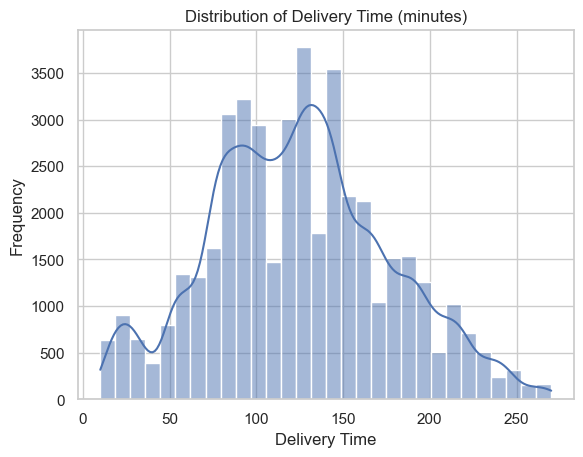

In [27]:
sns.histplot(df['Delivery_Time'], bins=30, kde=True)
plt.title("Distribution of Delivery Time (minutes)")
plt.xlabel("Delivery Time")
plt.ylabel("Frequency")
plt.show()

In [28]:
target = "Delivery_Time" 

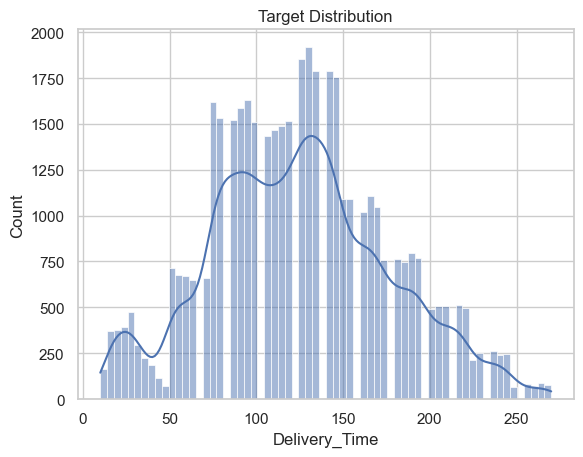

In [29]:
sns.histplot(df[target], kde=True)
plt.title("Target Distribution")
plt.show()

# Bivariate Analysis

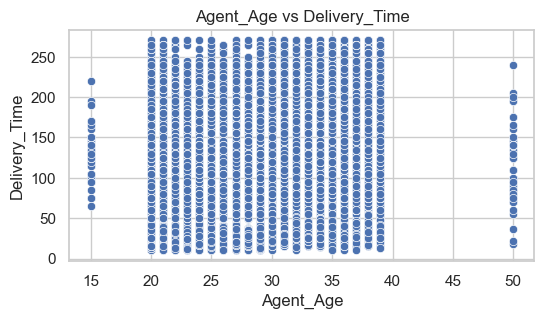

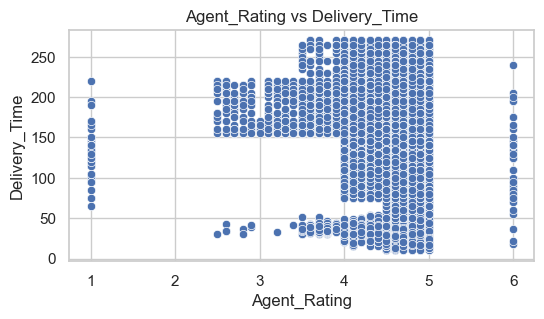

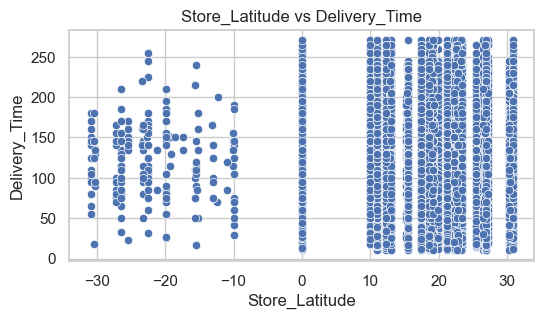

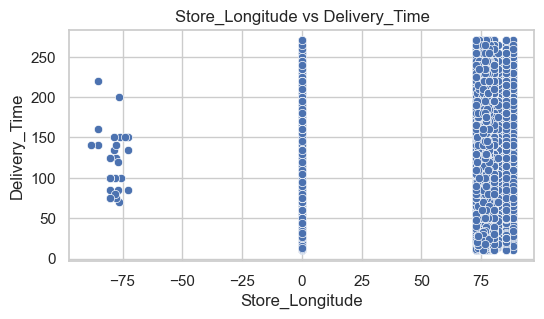

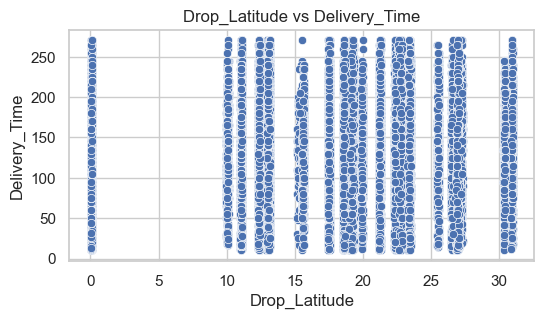

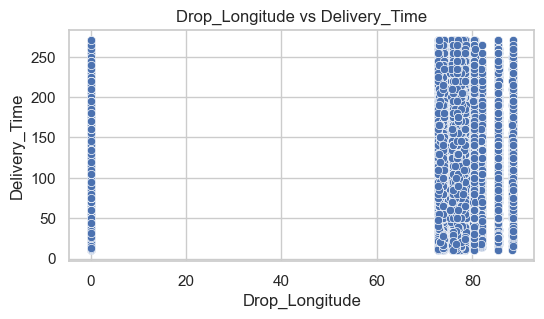

In [30]:
# Numerical vs Target
for col in num_cols:
    if col != target:
        plt.figure(figsize=(6,3))
        sns.scatterplot(x=df[col], y=df[target])
        plt.title(f"{col} vs {target}")
        plt.show()

In [ ]:
# # Categorical vs Target
# for col in cat_cols:
#     plt.figure(figsize=(6,3))
#     sns.boxplot(x=df[col], y=df[target])
#     plt.xticks(rotation=45)
#     plt.title(f"{col} vs {target}")
#     plt.show()

KeyboardInterrupt: 

### Boxplot – Delivery Time vs Weather

In [ ]:
sns.boxplot(x='Weather', y='Delivery_Time', data=df)
plt.xticks(rotation=45)
plt.title("Delivery Time by Weather")
plt.show()

### Boxplot – Delivery Time vs Traffic

In [ ]:
sns.boxplot(x='Traffic', y='Delivery_Time', data=df)
plt.title("Delivery Time by Traffic")
plt.show()

### Delivery Time vs Distance (Scatter)

In [ ]:
sns.scatterplot(x='Distance_km', y='Delivery_Time', data=df)
plt.title("Delivery Time vs Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (minutes)")
plt.show()

### Agent Rating vs Delivery Time

In [ ]:
sns.scatterplot(x='Agent_Rating', y='Delivery_Time', data=df)
plt.title("Agent Rating vs Delivery Time")
plt.show()

### Correlation Heatmap

In [ ]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### Delivery Time by Day of Week

In [ ]:
df.groupby('Order_DayOfWeek')['Delivery_Time'].mean().plot(kind='bar')
plt.title("Avg Delivery Time by Day of Week")
plt.xlabel("Day of Week (0 = Monday)")
plt.ylabel("Average Delivery Time")
plt.show()

### Save Processed Insights

In [ ]:
# Save summary stats or visualizations if needed
summary = df.describe()
summary.to_csv(r"D:\Guvi\Projects\mini\Amazon Delivery Time Prediction\Amazon_delivery_time_prediction\data\processed\summary_statistics.csv")
print("✅ Summary statistics saved.")